<a href="https://colab.research.google.com/github/Nikita-Puzyrev/ML-2026/blob/main/labwork2/labwork2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Данные уже загружены.
Файл прочитан: cp1252

Количество наблюдений: 8760


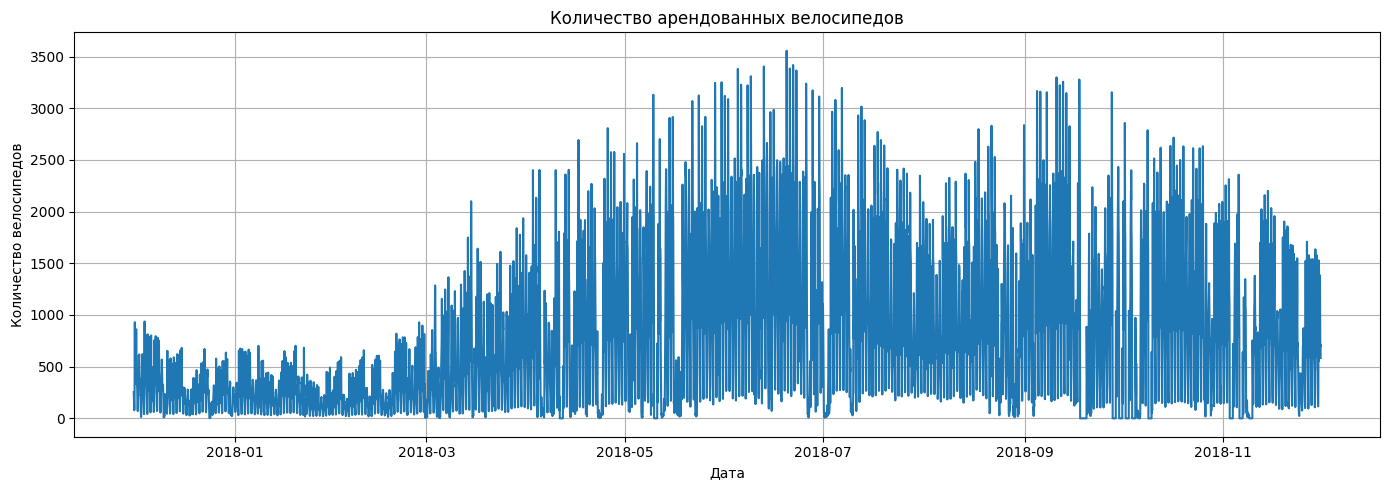


Размер Train: 6132
Размер Validation: 1314
Размер Test: 1314

X_train: (6108, 24)
X_val: (1314, 24)
X_test: (1314, 24)

Архитектура сети:
24 -> 16 -> 1
Эпоха   1/300 | Train MSE: 0.013796 | Val MSE: 0.028025
Эпоха  25/300 | Train MSE: 0.008457 | Val MSE: 0.016599
Эпоха  50/300 | Train MSE: 0.007712 | Val MSE: 0.014767
Эпоха  75/300 | Train MSE: 0.007235 | Val MSE: 0.013755
Эпоха 100/300 | Train MSE: 0.006844 | Val MSE: 0.012970
Эпоха 125/300 | Train MSE: 0.006510 | Val MSE: 0.012302
Эпоха 150/300 | Train MSE: 0.006221 | Val MSE: 0.011728
Эпоха 175/300 | Train MSE: 0.005968 | Val MSE: 0.011217
Эпоха 200/300 | Train MSE: 0.005744 | Val MSE: 0.010761
Эпоха 225/300 | Train MSE: 0.005543 | Val MSE: 0.010351
Эпоха 250/300 | Train MSE: 0.005362 | Val MSE: 0.009977
Эпоха 275/300 | Train MSE: 0.005201 | Val MSE: 0.009637
Эпоха 300/300 | Train MSE: 0.005054 | Val MSE: 0.009327

Результаты:
MAE = 205.54
RMSE = 285.61


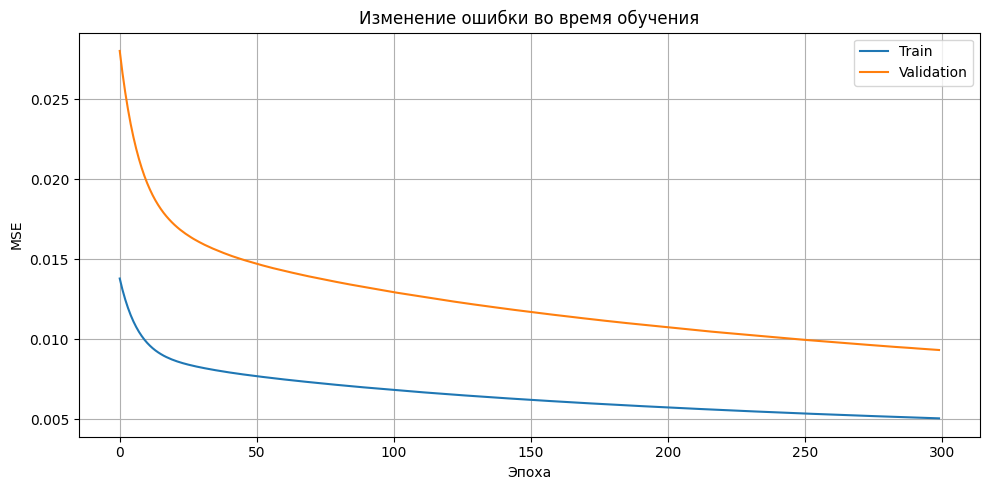

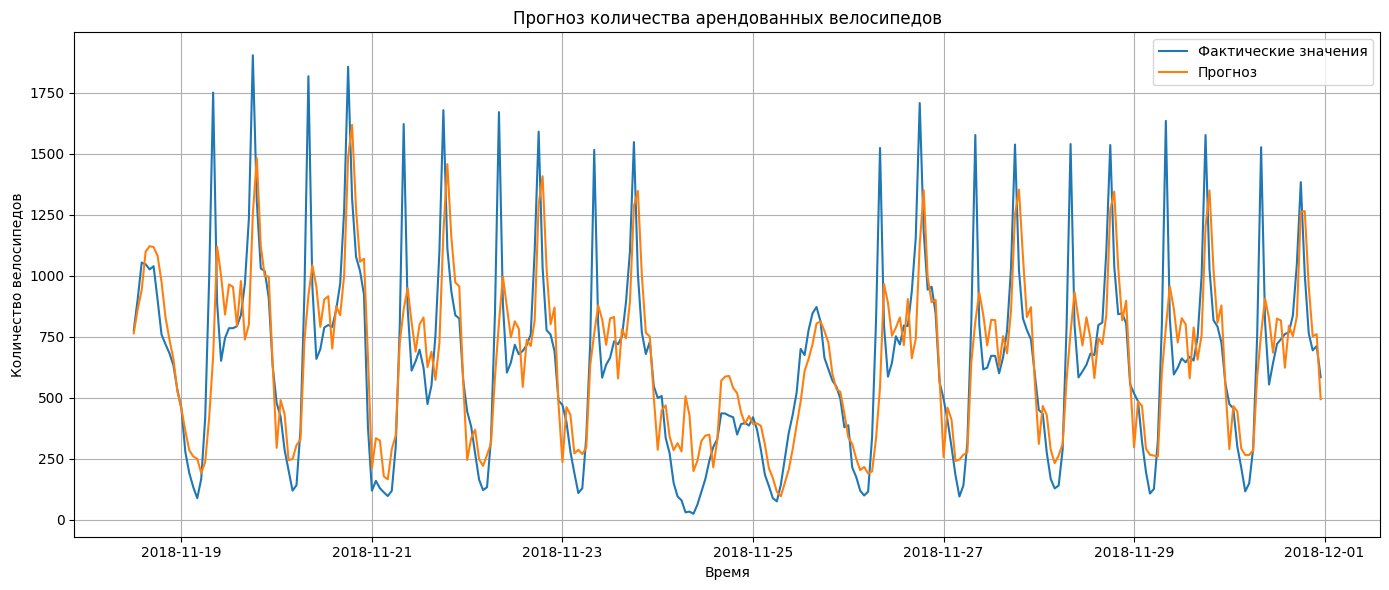

In [4]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. НАСТРОЙКИ
# ============================================================

DATA_URL = (
    "https://archive.ics.uci.edu/static/public/560/"
    "seoul%2Bbike%2Bsharing%2Bdemand.zip"
)

DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "seoul_bike.zip")

WINDOW_SIZE = 24

TRAIN_PART = 0.70
VAL_PART = 0.15

HIDDEN_SIZE = 16

LEARNING_RATE = 0.005
EPOCHS = 300
BATCH_SIZE = 128

RANDOM_SEED = 42


# ============================================================
# 2. ЗАГРУЗКА ДАННЫХ
# ============================================================

def download_dataset():

    os.makedirs(DATA_DIR, exist_ok=True)

    csv_path = os.path.join(
        DATA_DIR,
        "SeoulBikeData.csv"
    )

    if os.path.exists(csv_path):
        print("Данные уже загружены.")
        return csv_path

    print("Скачивание данных...")

    urllib.request.urlretrieve(
        DATA_URL,
        ZIP_PATH
    )

    print("Распаковка...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as archive:
        archive.extractall(DATA_DIR)

    print("Данные загружены.")

    return csv_path


# ============================================================
# 3. ЧТЕНИЕ CSV
# ============================================================

def load_dataframe(path):

    encodings = [
        "utf-8",
        "utf-8-sig",
        "cp1252",
        "latin1"
    ]

    for encoding in encodings:

        try:

            df = pd.read_csv(
                path,
                encoding=encoding
            )

            print(
                f"Файл прочитан: {encoding}"
            )

            return df

        except UnicodeDecodeError:
            pass

    raise RuntimeError(
        "Не удалось определить кодировку."
    )


# ============================================================
# 4. ПОДГОТОВКА ВРЕМЕННОГО РЯДА
# ============================================================

def prepare_series(df):

    target_column = "Rented Bike Count"

    df["Timestamp"] = (
        pd.to_datetime(
            df["Date"],
            dayfirst=True,
            errors="coerce"
        )
        +
        pd.to_timedelta(
            df["Hour"],
            unit="h"
        )
    )

    df = df.dropna(
        subset=["Timestamp"]
    )

    df = df.sort_values(
        "Timestamp"
    )

    values = (
        df[target_column]
        .astype(float)
        .to_numpy()
    )

    timestamps = (
        df["Timestamp"]
        .to_numpy()
    )

    return values, timestamps


# ============================================================
# 5. СОЗДАНИЕ ОКОН
# ============================================================

def create_windows(
    data,
    window_size
):

    X = []
    y = []

    for i in range(
        window_size,
        len(data)
    ):

        X.append(
            data[
                i - window_size:i
            ]
        )

        y.append(
            data[i]
        )

    X = np.array(X)

    y = np.array(
        y
    ).reshape(-1, 1)

    return X, y


# ============================================================
# 6. НОРМАЛИЗАЦИЯ
# ============================================================

def normalize(
    data,
    minimum,
    maximum
):

    return (
        (data - minimum)
        /
        (maximum - minimum)
    )


def denormalize(
    data,
    minimum,
    maximum
):

    return (
        data
        *
        (maximum - minimum)
        +
        minimum
    )


# ============================================================
# 7. НЕЙРОННАЯ СЕТЬ
# ============================================================

class NeuralNetwork:

    def __init__(
        self,
        input_size,
        hidden_size,
        learning_rate,
        seed=42
    ):

        self.learning_rate = (
            learning_rate
        )

        rng = np.random.default_rng(
            seed
        )

        # ----------------------------------------------------
        # Первый слой:
        #
        # 24 входа -> 16 нейронов
        # ----------------------------------------------------

        self.W1 = rng.normal(
            0,
            np.sqrt(
                2 / input_size
            ),
            size=(
                input_size,
                hidden_size
            )
        )

        self.b1 = np.zeros(
            (1, hidden_size)
        )

        # ----------------------------------------------------
        # Второй слой:
        #
        # 16 нейронов -> 1 выход
        # ----------------------------------------------------

        self.W2 = rng.normal(
            0,
            np.sqrt(
                2 / hidden_size
            ),
            size=(
                hidden_size,
                1
            )
        )

        self.b2 = np.zeros(
            (1, 1)
        )

        self.train_loss_history = []
        self.val_loss_history = []


    # ========================================================
    # ReLU
    # ========================================================

    @staticmethod
    def relu(x):

        return np.maximum(
            0,
            x
        )


    # ========================================================
    # Производная ReLU
    # ========================================================

    @staticmethod
    def relu_derivative(x):

        return (
            x > 0
        ).astype(float)


    # ========================================================
    # MSE
    # ========================================================

    @staticmethod
    def mse(
        real,
        predicted
    ):

        return np.mean(
            (
                real
                -
                predicted
            ) ** 2
        )


    # ========================================================
    # ПРЯМОЕ РАСПРОСТРАНЕНИЕ
    # ========================================================

    def forward(self, X):

        # Первый слой

        self.Z1 = (
            X @ self.W1
            +
            self.b1
        )

        # ReLU

        self.A1 = self.relu(
            self.Z1
        )

        # Выходной слой

        self.Y_pred = (
            self.A1 @ self.W2
            +
            self.b2
        )

        return self.Y_pred


    # ========================================================
    # ОБРАТНОЕ РАСПРОСТРАНЕНИЕ
    # ========================================================

    def backward(
        self,
        X,
        y
    ):

        n = X.shape[0]

        # ----------------------------------------------------
        # Производная MSE
        # ----------------------------------------------------

        dY = (
            2
            *
            (
                self.Y_pred
                -
                y
            )
            /
            n
        )

        # ----------------------------------------------------
        # Градиенты второго слоя
        # ----------------------------------------------------

        dW2 = (
            self.A1.T
            @
            dY
        )

        db2 = np.sum(
            dY,
            axis=0,
            keepdims=True
        )

        # ----------------------------------------------------
        # Передача ошибки назад
        # ----------------------------------------------------

        dA1 = (
            dY
            @
            self.W2.T
        )

        dZ1 = (
            dA1
            *
            self.relu_derivative(
                self.Z1
            )
        )

        # ----------------------------------------------------
        # Градиенты первого слоя
        # ----------------------------------------------------

        dW1 = (
            X.T
            @
            dZ1
        )

        db1 = np.sum(
            dZ1,
            axis=0,
            keepdims=True
        )

        # ----------------------------------------------------
        # Градиентный спуск
        # ----------------------------------------------------

        self.W1 -= (
            self.learning_rate
            *
            dW1
        )

        self.b1 -= (
            self.learning_rate
            *
            db1
        )

        self.W2 -= (
            self.learning_rate
            *
            dW2
        )

        self.b2 -= (
            self.learning_rate
            *
            db2
        )


    # ========================================================
    # ОБУЧЕНИЕ
    # ========================================================

    def train(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs,
        batch_size
    ):

        rng = np.random.default_rng(
            RANDOM_SEED
        )

        for epoch in range(
            epochs
        ):

            # -----------------------------------------------
            # Перемешиваем обучающие окна
            # -----------------------------------------------

            indexes = rng.permutation(
                len(X_train)
            )

            # -----------------------------------------------
            # Обучение по mini-batch
            # -----------------------------------------------

            for start in range(
                0,
                len(X_train),
                batch_size
            ):

                batch_indexes = (
                    indexes[
                        start:
                        start + batch_size
                    ]
                )

                X_batch = (
                    X_train[
                        batch_indexes
                    ]
                )

                y_batch = (
                    y_train[
                        batch_indexes
                    ]
                )

                # Прямой проход

                self.forward(
                    X_batch
                )

                # Обратный проход

                self.backward(
                    X_batch,
                    y_batch
                )

            # -----------------------------------------------
            # Ошибка Train
            # -----------------------------------------------

            train_pred = (
                self.forward(
                    X_train
                )
            )

            train_loss = (
                self.mse(
                    y_train,
                    train_pred
                )
            )

            # -----------------------------------------------
            # Ошибка Validation
            # -----------------------------------------------

            val_pred = (
                self.forward(
                    X_val
                )
            )

            val_loss = (
                self.mse(
                    y_val,
                    val_pred
                )
            )

            self.train_loss_history.append(
                train_loss
            )

            self.val_loss_history.append(
                val_loss
            )

            # -----------------------------------------------
            # Вывод состояния обучения
            # -----------------------------------------------

            if (
                epoch == 0
                or
                (epoch + 1) % 25 == 0
            ):

                print(
                    f"Эпоха "
                    f"{epoch + 1:3d}/"
                    f"{epochs} | "
                    f"Train MSE: "
                    f"{train_loss:.6f} | "
                    f"Val MSE: "
                    f"{val_loss:.6f}"
                )


    # ========================================================
    # ПРОГНОЗ
    # ========================================================

    def predict(self, X):

        return self.forward(X)


# ============================================================
# 8. МЕТРИКИ
# ============================================================

def calculate_mae(
    real,
    predicted
):

    return np.mean(
        np.abs(
            real
            -
            predicted
        )
    )


def calculate_rmse(
    real,
    predicted
):

    return np.sqrt(
        np.mean(
            (
                real
                -
                predicted
            ) ** 2
        )
    )


# ============================================================
# 9. ОСНОВНАЯ ПРОГРАММА
# ============================================================

def main():

    # ========================================================
    # ШАГ 1. Загрузка данных
    # ========================================================

    path = download_dataset()

    df = load_dataframe(
        path
    )

    values, timestamps = (
        prepare_series(df)
    )

    print(
        "\nКоличество наблюдений:",
        len(values)
    )

    # ========================================================
    # ШАГ 2. Исходный временной ряд
    # ========================================================

    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        timestamps,
        values
    )

    plt.title(
        "Количество арендованных велосипедов"
    )

    plt.xlabel(
        "Дата"
    )

    plt.ylabel(
        "Количество велосипедов"
    )

    plt.grid()

    plt.tight_layout()

    plt.show()

    # ========================================================
    # ШАГ 3. Train / Validation / Test
    # ========================================================

    n = len(values)

    train_end = int(
        n * TRAIN_PART
    )

    val_end = int(
        n * (
            TRAIN_PART
            +
            VAL_PART
        )
    )

    print(
        "\nРазмер Train:",
        train_end
    )

    print(
        "Размер Validation:",
        val_end - train_end
    )

    print(
        "Размер Test:",
        n - val_end
    )

    # ========================================================
    # ШАГ 4. Нормализация
    #
    # Минимум и максимум берём только из Train
    # ========================================================

    train_values = (
        values[:train_end]
    )

    train_min = (
        train_values.min()
    )

    train_max = (
        train_values.max()
    )

    normalized_values = normalize(
        values,
        train_min,
        train_max
    )

    # ========================================================
    # ШАГ 5. Создание окон
    # ========================================================

    X_train, y_train = (
        create_windows(
            normalized_values[
                :train_end
            ],
            WINDOW_SIZE
        )
    )

    val_data = (
        normalized_values[
            train_end
            -
            WINDOW_SIZE
            :
            val_end
        ]
    )

    X_val, y_val = (
        create_windows(
            val_data,
            WINDOW_SIZE
        )
    )

    test_data = (
        normalized_values[
            val_end
            -
            WINDOW_SIZE
            :
        ]
    )

    X_test, y_test = (
        create_windows(
            test_data,
            WINDOW_SIZE
        )
    )

    test_timestamps = (
        timestamps[
            val_end:
        ]
    )

    print(
        "\nX_train:",
        X_train.shape
    )

    print(
        "X_val:",
        X_val.shape
    )

    print(
        "X_test:",
        X_test.shape
    )

    # ========================================================
    # ШАГ 6. Создание нейронной сети
    # ========================================================

    model = NeuralNetwork(

        input_size=WINDOW_SIZE,

        hidden_size=HIDDEN_SIZE,

        learning_rate=LEARNING_RATE,

        seed=RANDOM_SEED
    )

    print(
        "\nАрхитектура сети:"
    )

    print(
        f"{WINDOW_SIZE} "
        f"-> "
        f"{HIDDEN_SIZE} "
        f"-> 1"
    )

    # ========================================================
    # ШАГ 7. Обучение
    # ========================================================

    model.train(

        X_train,
        y_train,

        X_val,
        y_val,

        epochs=EPOCHS,

        batch_size=BATCH_SIZE
    )

    # ========================================================
    # ШАГ 8. Прогноз
    # ========================================================

    prediction_norm = (
        model.predict(
            X_test
        )
    )

    # Возвращаем исходный масштаб

    prediction = (
        denormalize(
            prediction_norm,
            train_min,
            train_max
        )
    )

    real = (
        denormalize(
            y_test,
            train_min,
            train_max
        )
    )

    # ========================================================
    # ШАГ 9. Оценка качества
    # ========================================================

    mae = calculate_mae(
        real,
        prediction
    )

    rmse = calculate_rmse(
        real,
        prediction
    )

    print(
        "\nРезультаты:"
    )

    print(
        f"MAE = {mae:.2f}"
    )

    print(
        f"RMSE = {rmse:.2f}"
    )

    # ========================================================
    # ШАГ 10. График обучения
    # ========================================================

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        model.train_loss_history,
        label="Train"
    )

    plt.plot(
        model.val_loss_history,
        label="Validation"
    )

    plt.title(
        "Изменение ошибки во время обучения"
    )

    plt.xlabel(
        "Эпоха"
    )

    plt.ylabel(
        "MSE"
    )

    plt.legend()

    plt.grid()

    plt.tight_layout()

    plt.show()

    # ========================================================
    # ШАГ 11. График прогноза
    # ========================================================

    count = 300

    plt.figure(
        figsize=(14, 6)
    )

    plt.plot(
        test_timestamps[-count:],
        real[-count:],
        label="Фактические значения"
    )

    plt.plot(
        test_timestamps[-count:],
        prediction[-count:],
        label="Прогноз"
    )

    plt.title(
        "Прогноз количества арендованных велосипедов"
    )

    plt.xlabel(
        "Время"
    )

    plt.ylabel(
        "Количество велосипедов"
    )

    plt.legend()

    plt.grid()

    plt.tight_layout()

    plt.show()


# ============================================================
# ЗАПУСК
# ============================================================

if __name__ == "__main__":
    main()

#С библиотеками sklearn и tensorflow

Данные уже загружены.
Файл прочитан: cp1252

Количество наблюдений: 8760


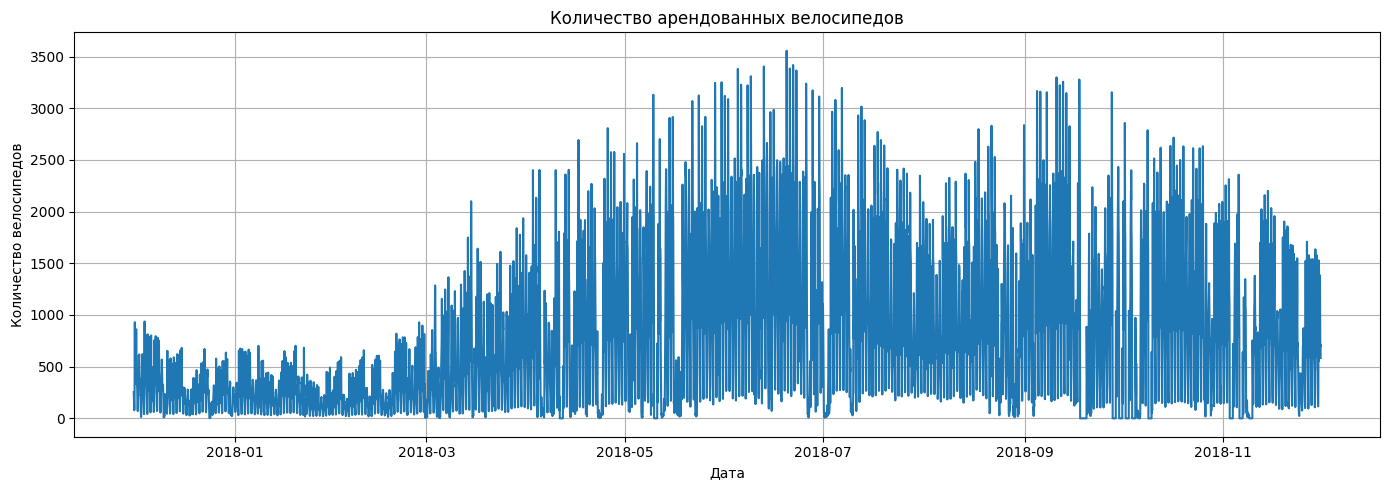


Размер Train: 6132
Размер Validation: 1314
Размер Test: 1314

Размер X_train: (6108, 24)
Размер X_val: (1314, 24)
Размер X_test: (1314, 24)

Архитектура нейронной сети:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0119 - mae: 0.0646 - val_loss: 0.0147 - val_mae: 0.0848
Epoch 2/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057 - mae: 0.0461 - val_loss: 0.0091 - val_mae: 0.0670
Epoch 3/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042 - mae: 0.0409 - val_loss: 0.0067 - val_mae: 0.0584
Epoch 4/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034 - mae: 0.0370 - val_loss: 0.0055 - val_mae: 0.0522
Epoch 5/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - mae: 0.0349 - val_loss: 0.0052 - val_mae: 0.0511
Epoch 6/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028 - mae: 0.0330 - val_loss: 0.0047 - val_mae: 0.0477
Epoch 7/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - mae: 0.0319 - val_loss: 0.0044 - val_mae: 0.0476
Epoch 8/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025 - mae: 0.0312 - val_loss: 0.0042 - val_mae: 0.0452
Epoch 9/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

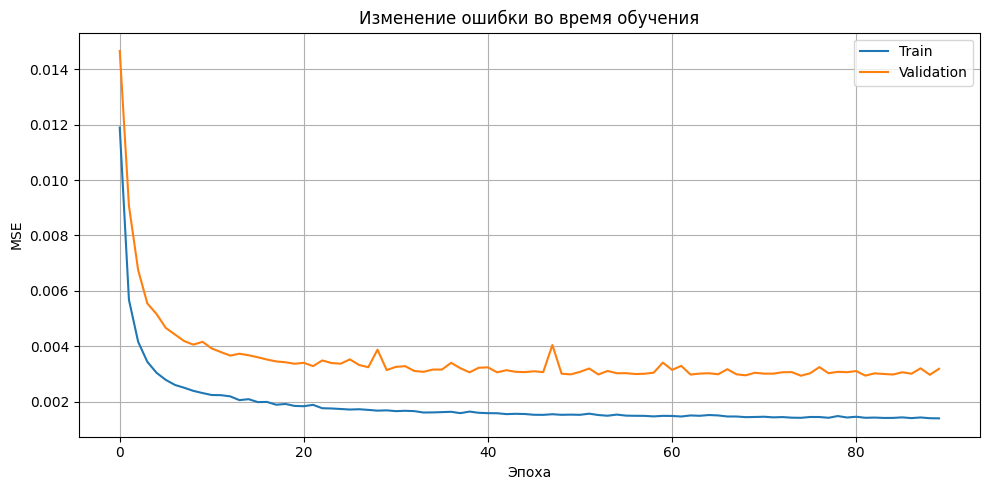

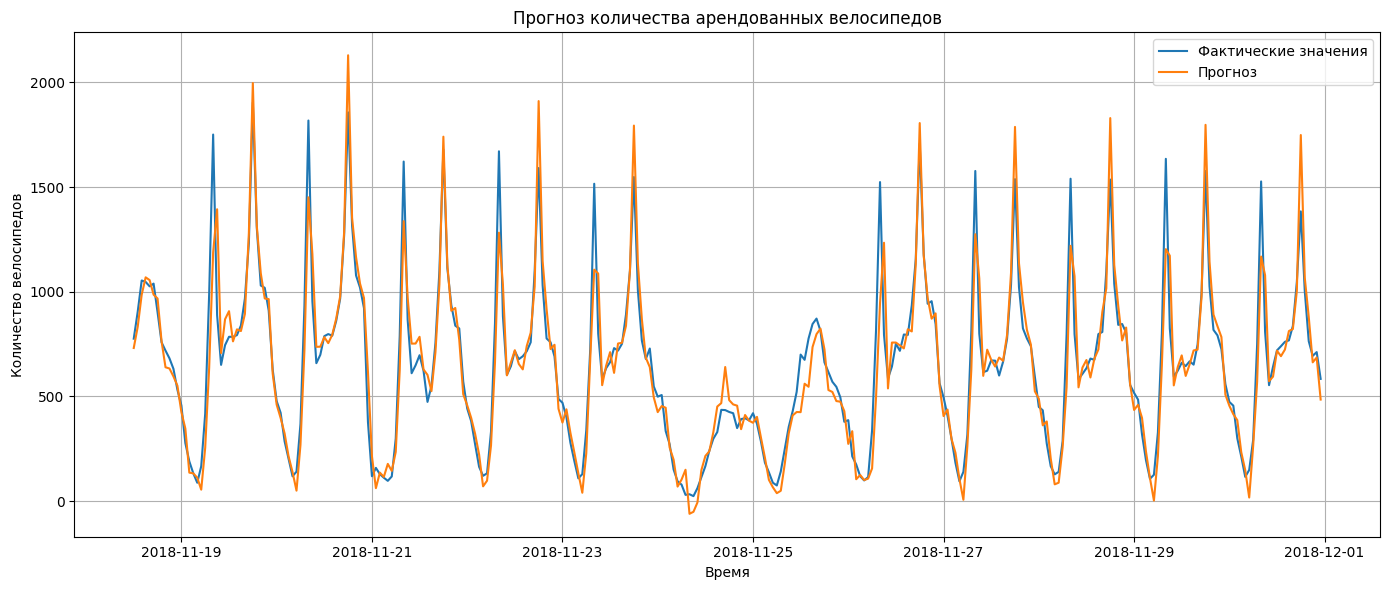

In [5]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. НАСТРОЙКИ
# ============================================================

DATA_URL = (
    "https://archive.ics.uci.edu/static/public/560/"
    "seoul%2Bbike%2Bsharing%2Bdemand.zip"
)

DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "seoul_bike.zip")

WINDOW_SIZE = 24

TRAIN_PART = 0.70
VAL_PART = 0.15

HIDDEN_SIZE = 16

LEARNING_RATE = 0.001
EPOCHS = 200
BATCH_SIZE = 32


# ============================================================
# 2. ЗАГРУЗКА ДАННЫХ
# ============================================================

def download_dataset():

    os.makedirs(
        DATA_DIR,
        exist_ok=True
    )

    csv_path = os.path.join(
        DATA_DIR,
        "SeoulBikeData.csv"
    )

    if os.path.exists(csv_path):

        print(
            "Данные уже загружены."
        )

        return csv_path

    print(
        "Скачивание данных..."
    )

    urllib.request.urlretrieve(
        DATA_URL,
        ZIP_PATH
    )

    print(
        "Распаковка..."
    )

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as archive:

        archive.extractall(
            DATA_DIR
        )

    print(
        "Данные загружены."
    )

    return csv_path


# ============================================================
# 3. ЧТЕНИЕ CSV
# ============================================================

def load_dataframe(path):

    encodings = [
        "utf-8",
        "utf-8-sig",
        "cp1252",
        "latin1"
    ]

    for encoding in encodings:

        try:

            df = pd.read_csv(
                path,
                encoding=encoding
            )

            print(
                f"Файл прочитан: {encoding}"
            )

            return df

        except UnicodeDecodeError:

            pass

    raise RuntimeError(
        "Не удалось определить кодировку."
    )


# ============================================================
# 4. ПОДГОТОВКА ВРЕМЕННОГО РЯДА
# ============================================================

def prepare_series(df):

    target_column = (
        "Rented Bike Count"
    )

    # Объединяем дату и час
    # в полноценную временную метку

    df["Timestamp"] = (

        pd.to_datetime(
            df["Date"],
            dayfirst=True,
            errors="coerce"
        )

        +

        pd.to_timedelta(
            df["Hour"],
            unit="h"
        )

    )

    # Удаляем строки,
    # где время определить не удалось

    df = df.dropna(
        subset=["Timestamp"]
    )

    # Сортируем по времени

    df = df.sort_values(
        "Timestamp"
    )

    # Целевой временной ряд

    values = (

        df[target_column]

        .astype(float)

        .to_numpy()

        .reshape(-1, 1)

    )

    timestamps = (

        df["Timestamp"]

        .to_numpy()

    )

    return values, timestamps


# ============================================================
# 5. СОЗДАНИЕ ВРЕМЕННЫХ ОКОН
# ============================================================

def create_windows(
    data,
    window_size
):

    X = []
    y = []

    for i in range(
        window_size,
        len(data)
    ):

        # Предыдущие 24 часа

        X.append(

            data[
                i - window_size:i,
                0
            ]

        )

        # Следующий час

        y.append(
            data[i, 0]
        )

    return (
        np.array(X),
        np.array(y)
    )


# ============================================================
# 6. СОЗДАНИЕ НЕЙРОННОЙ СЕТИ
# ============================================================

def create_model():

    model = Sequential(

        [
            # Вход:
            # 24 предыдущих значения

            Input(
                shape=(WINDOW_SIZE,)
            ),

            # Скрытый слой

            Dense(
                HIDDEN_SIZE,
                activation="relu"
            ),

            # Выходной слой

            Dense(
                1
            )
        ]

    )

    # Оптимизатор Adam

    optimizer = Adam(
        learning_rate=LEARNING_RATE
    )

    # Настройка модели

    model.compile(

        optimizer=optimizer,

        loss="mse",

        metrics=["mae"]
    )

    return model


# ============================================================
# 7. ОСНОВНАЯ ПРОГРАММА
# ============================================================

def main():

    # ========================================================
    # ШАГ 1. Загрузка данных
    # ========================================================

    path = download_dataset()

    df = load_dataframe(
        path
    )

    values, timestamps = (
        prepare_series(df)
    )

    print(
        "\nКоличество наблюдений:",
        len(values)
    )

    # ========================================================
    # ШАГ 2. Исходный временной ряд
    # ========================================================

    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        timestamps,
        values
    )

    plt.title(
        "Количество арендованных велосипедов"
    )

    plt.xlabel(
        "Дата"
    )

    plt.ylabel(
        "Количество велосипедов"
    )

    plt.grid()

    plt.tight_layout()

    plt.show()

    # ========================================================
    # ШАГ 3. Train / Validation / Test
    # ========================================================

    n = len(values)

    train_end = int(
        n * TRAIN_PART
    )

    val_end = int(

        n
        *
        (
            TRAIN_PART
            +
            VAL_PART
        )

    )

    print(
        "\nРазмер Train:",
        train_end
    )

    print(
        "Размер Validation:",
        val_end - train_end
    )

    print(
        "Размер Test:",
        n - val_end
    )

    # ========================================================
    # ШАГ 4. Нормализация
    # ========================================================

    scaler = MinMaxScaler()

    # ВАЖНО:
    # scaler обучается только на Train

    scaler.fit(
        values[:train_end]
    )

    normalized_values = (
        scaler.transform(values)
    )

    # ========================================================
    # ШАГ 5. Создание временных окон
    # ========================================================

    # ---------------------------
    # Train
    # ---------------------------

    X_train, y_train = (
        create_windows(

            normalized_values[
                :train_end
            ],

            WINDOW_SIZE

        )
    )

    # ---------------------------
    # Validation
    # ---------------------------

    val_data = (

        normalized_values[
            train_end - WINDOW_SIZE:
            val_end
        ]

    )

    X_val, y_val = (
        create_windows(
            val_data,
            WINDOW_SIZE
        )
    )

    # ---------------------------
    # Test
    # ---------------------------

    test_data = (

        normalized_values[
            val_end - WINDOW_SIZE:
        ]

    )

    X_test, y_test = (
        create_windows(
            test_data,
            WINDOW_SIZE
        )
    )

    test_timestamps = (
        timestamps[
            val_end:
        ]
    )

    print(
        "\nРазмер X_train:",
        X_train.shape
    )

    print(
        "Размер X_val:",
        X_val.shape
    )

    print(
        "Размер X_test:",
        X_test.shape
    )

    # ========================================================
    # ШАГ 6. Создание нейронной сети
    # ========================================================

    model = create_model()

    print(
        "\nАрхитектура нейронной сети:"
    )

    model.summary()

    # ========================================================
    # ШАГ 7. EarlyStopping
    # ========================================================

    early_stopping = EarlyStopping(

        # Следим за ошибкой
        # на validation

        monitor="val_loss",

        # Сколько эпох ждать
        # улучшения

        patience=15,

        # Вернуть лучшие веса

        restore_best_weights=True
    )

    # ========================================================
    # ШАГ 8. Обучение
    # ========================================================

    history = model.fit(

        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=[
            early_stopping
        ],

        verbose=1
    )

    # ========================================================
    # ШАГ 9. Прогноз
    # ========================================================

    prediction_norm = (
        model.predict(
            X_test,
            verbose=0
        )
    )

    # Возвращаем прогноз
    # в исходный масштаб

    prediction = (
        scaler.inverse_transform(
            prediction_norm
        )
    )

    # То же самое
    # для реальных значений

    real = (
        scaler.inverse_transform(

            y_test.reshape(
                -1,
                1
            )

        )
    )

    # ========================================================
    # ШАГ 10. Оценка качества
    # ========================================================

    mae = mean_absolute_error(
        real,
        prediction
    )

    rmse = np.sqrt(

        mean_squared_error(
            real,
            prediction
        )

    )

    print(
        "\nРезультаты:"
    )

    print(
        f"MAE = {mae:.2f}"
    )

    print(
        f"RMSE = {rmse:.2f}"
    )

    # ========================================================
    # ШАГ 11. График обучения
    # ========================================================

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(

        history.history[
            "loss"
        ],

        label="Train"
    )

    plt.plot(

        history.history[
            "val_loss"
        ],

        label="Validation"
    )

    plt.title(
        "Изменение ошибки во время обучения"
    )

    plt.xlabel(
        "Эпоха"
    )

    plt.ylabel(
        "MSE"
    )

    plt.legend()

    plt.grid()

    plt.tight_layout()

    plt.show()

    # ========================================================
    # ШАГ 12. График прогноза
    # ========================================================

    count = 300

    plt.figure(
        figsize=(14, 6)
    )

    plt.plot(

        test_timestamps[
            -count:
        ],

        real[
            -count:
        ],

        label="Фактические значения"
    )

    plt.plot(

        test_timestamps[
            -count:
        ],

        prediction[
            -count:
        ],

        label="Прогноз"
    )

    plt.title(
        "Прогноз количества арендованных велосипедов"
    )

    plt.xlabel(
        "Время"
    )

    plt.ylabel(
        "Количество велосипедов"
    )

    plt.legend()

    plt.grid()

    plt.tight_layout()

    plt.show()


# ============================================================
# ЗАПУСК
# ============================================================

if __name__ == "__main__":

    main()